In [2]:
import os
import sys

import numpy as np
import math
import uproot as uproot
import pickle
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec

# Add the head direcoty to sys.path
workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/../../../")

# import this repo's classes
import pyanalib.pandas_helpers as ph
from makedf.util import *

#import dunestyle.matplotlib as dunestyle


In [3]:
venv_path = os.getenv("PATH")

In [4]:
input_path = "/exp/sbnd/data/users/sungbino/sbnd_samples/cafpyana_outputs/"
mc_file = input_path + "Spring25Dev_MC_bnb_cosmics_v10_04_06_01_nosce_pandora.df"
data_file = input_path + "Spring25Dev_data_new_ccal_v10_04_06_01_nosce_pandora.df"

In [11]:
mc_hdr_df = pd.read_hdf(mc_file, key='hdr')
#mc_evt_df = pd.read_hdf(mc_file, key='evt')
mc_nu_df = pd.read_hdf(mc_file, key='mcnu')

data_hdr_df = pd.read_hdf(data_file, key='hdr')
#data_evt_df = pd.read_hdf(data_file, key='evt')

In [8]:
mc_hdr_df

pot  first_in_subrun  ismc  run  subrun  ngenevt  \
__ntuple entry                                                              
10       0      1.513442e+15                1     1  115      20      100   
         1      0.000000e+00                0     1  115      20      100   
         2      0.000000e+00                0     1  115      20      100   
         3      0.000000e+00                0     1  115      20      100   
         4      0.000000e+00                0     1  115      20      100   
...                      ...              ...   ...  ...     ...      ...   
1581     159    0.000000e+00                0     1   73      92      100   
         160    0.000000e+00                0     1   73      92      100   
         161    0.000000e+00                0     1   73      92      100   
         162    0.000000e+00                0     1   73      92      100   
         163    0.000000e+00                0     1   73      92      100   

                evt  proc   cluster  fno  
__ntuple entry                            
10       0       10   107  19871273    0  
         1       17   107  19871273    0  
         2       22   107  19871273    0  
         3       27   107  19871273    0  
         4       32   107  19871273    0  
...             ...   ...       ...  ...  
1581     159     39    82  76153747    8  
         160     55    82  76153747    8  
         161     72    82  76153747    8  
         162     76    82  76153747    8  
         163     96    82  76153747    8  

[269486 rows x 10 columns]

In [9]:
data_hdr_df

pot  first_in_subrun  ismc    run  subrun  ngenevt     evt  \
__ntuple entry                                                               
23       0      0.0                1     0  18255       1        0  392373   
         1      0.0                0     0  18255       1        0  392417   
         2      0.0                0     0  18255       1        0  392483   
         3      0.0                0     0  18255       1        0  392527   
         4      0.0                0     0  18255       1        0  392637   
...             ...              ...   ...    ...     ...      ...     ...   
496      195    0.0                0     0  18255       1        0  205985   
         196    0.0                0     0  18255       1        0  206161   
         197    0.0                0     0  18255       1        0  206425   
         198    0.0                0     0  18255       1        0  206711   
         199    0.0                0     0  18255       1        0  206909   

                proc   cluster  fno  
__ntuple entry                       
23       0       119  76206657    0  
         1       119  76206657    0  
         2       119  76206657    0  
         3       119  76206657    0  
         4       119  76206657    0  
...              ...       ...  ...  
496      195      96  76206657    3  
         196      96  76206657    3  
         197      96  76206657    3  
         198      96  76206657    3  
         199      96  76206657    3  

[93907 rows x 10 columns]

In [10]:
mc_tot_pot = mc_hdr_df['pot'].sum()
data_tot_pot = data_hdr_df['pot'].sum()

print("mc_tot_pot: %e, data_tot_pot: %e" %(mc_tot_pot, data_tot_pot))
#POT_scale = target_POT / this_pot
#print(POT_scale)

mc_tot_pot: 2.320516e+19, data_tot_pot: 0.000000e+00


In [12]:
mc_nu_df

E      time  bjorkenX inelasticityY  \
                                                                              
                                                                              
__ntuple entry rec.mc.nu..index                                               
10       0     0                 0.466995  0.952679  1.012430      0.125459   
               1                 0.944120  0.550360  1.253764      0.358597   
         1     0                 0.634453  1.144243  0.317071      0.586196   
               1                 1.015173  1.767044  0.743862      0.215484   
         2     0                 1.497209  1.585625  0.385837      0.139724   
...                                   ...       ...       ...           ...   
1581     160   1                 0.650978  0.512085  0.630376      0.366766   
         161   0                 0.954031  1.723123  0.924489      0.418920   
               1                 2.129150  1.585114  0.443421      0.096732   
         162   0                 1.053319  1.640669  0.633017      0.250502   
         163   0                 0.614793  1.330277  1.429214      0.292205   

                                       Q2         w  momentum            \
                                                            x         y   
                                                                          
__ntuple entry rec.mc.nu..index                                           
10       0     0                 0.111388  0.938190  0.013552 -0.019786   
               1                 0.797090  0.848667 -0.012923  0.015781   
         1     0                 0.221440  1.165556  0.022466  0.007328   
               1                 0.305566  0.993371 -0.006327  0.020309   
         2     0                 0.151571  1.059639 -0.010561 -0.026335   
...                                   ...       ...       ...       ...   
1581     160   1                 0.282626  1.023371  0.004923 -0.009734   
         161   0                 0.693831  0.968628 -0.006377  0.006870   
               1                 0.171495  1.047295  0.045166  0.117113   
         162   0                 0.313649  1.031214  0.028852 -0.005238   
         163   0                 0.482139  0.858356  0.001216  0.008444   

                                             position  ...         p  \
                                        z           x  ...      genp   
                                                       ...         x   
__ntuple entry rec.mc.nu..index                        ...             
10       0     0                 0.466379  238.716797  ...       NaN   
               1                 0.943900 -230.194672  ... -0.550995   
         1     0                 0.634012  137.609192  ...  0.104895   
               1                 1.014950 -135.814606  ... -0.156583   
         2     0                 1.496940 -195.547348  ... -0.235737   
...                                   ...         ...  ...       ...   
1581     160   1                 0.650887    9.073294  ... -0.198944   
         161   0                 0.953985  -88.869316  ... -0.354848   
               1                 2.125447  158.006989  ...       NaN   
         162   0                 1.052911   20.910109  ... -0.420506   
         163   0                 0.614733  -47.765835  ... -0.083598   

                                                                               \
                                                           start                
                                        y         z            x            y   
__ntuple entry rec.mc.nu..index                                                 
10       0     0                      NaN       NaN          NaN          NaN   
               1                 0.123894  0.607047 -9999.000000 -9999.000000   
         1     0                -0.123286  0.256586 -9999.000000 -9999.000000   
               1                 0.458286  0.418498 -9999.000000 -9999.000000   

In [13]:
mc_nu_df.columns

MultiIndex([(            'E',       '',  ''),
            (         'time',       '',  ''),
            (     'bjorkenX',       '',  ''),
            ('inelasticityY',       '',  ''),
            (           'Q2',       '',  ''),
            (            'w',       '',  ''),
            (     'momentum',      'x',  ''),
            (     'momentum',      'y',  ''),
            (     'momentum',      'z',  ''),
            (     'position',      'x',  ''),
            (     'position',      'y',  ''),
            (     'position',      'z',  ''),
            (          'pdg',       '',  ''),
            (         'iscc',       '',  ''),
            (   'genie_mode',       '',  ''),
            (   'parent_pdg',       '',  ''),
            ( 'parent_dcy_E',       '',  ''),
            ('max_proton_ke',       '',  ''),
            (           'nn',       '',  ''),
            (           'np',       '',  ''),
            (          'nmu',       '',  ''),
            (          'npi',     

In [14]:
is_fv = InFV(mc_nu_df.position, 0, 0, 0, 0, "SBND")
is_cc = mc_nu_df.iscc
genie_mode = mc_nu_df.genie_mode
nuint_categ = pd.Series(8, index=mc_nu_df.index)
nuint_categ[~is_fv] = -1  # Out of FV
nuint_categ[is_fv & ~is_cc] = 0  # NC
nuint_categ[is_fv & is_cc & (genie_mode == 3)] = 1  # CCCOH
nuint_categ[is_fv & is_cc & (genie_mode == 0)] = 2  # CCQE
nuint_categ[is_fv & is_cc & (genie_mode == 10)] = 3  # 2p2h
nuint_categ[is_fv & is_cc & (genie_mode != 0) & (genie_mode != 3) & (genie_mode != 10) & (genie_mode == 1)] = 4  # RES
nuint_categ[is_fv & is_cc & (genie_mode != 0) & (genie_mode != 3) & (genie_mode != 10) & (genie_mode == 2)] = 5  # DIS

In [15]:
mc_nu_df['nuint_categ'] = nuint_categ

In [17]:
mc_nu_df

E      time  bjorkenX inelasticityY  \
                                                                              
                                                                              
__ntuple entry rec.mc.nu..index                                               
10       0     0                 0.466995  0.952679  1.012430      0.125459   
               1                 0.944120  0.550360  1.253764      0.358597   
         1     0                 0.634453  1.144243  0.317071      0.586196   
               1                 1.015173  1.767044  0.743862      0.215484   
         2     0                 1.497209  1.585625  0.385837      0.139724   
...                                   ...       ...       ...           ...   
1581     160   1                 0.650978  0.512085  0.630376      0.366766   
         161   0                 0.954031  1.723123  0.924489      0.418920   
               1                 2.129150  1.585114  0.443421      0.096732   
         162   0                 1.053319  1.640669  0.633017      0.250502   
         163   0                 0.614793  1.330277  1.429214      0.292205   

                                       Q2         w  momentum            \
                                                            x         y   
                                                                          
__ntuple entry rec.mc.nu..index                                           
10       0     0                 0.111388  0.938190  0.013552 -0.019786   
               1                 0.797090  0.848667 -0.012923  0.015781   
         1     0                 0.221440  1.165556  0.022466  0.007328   
               1                 0.305566  0.993371 -0.006327  0.020309   
         2     0                 0.151571  1.059639 -0.010561 -0.026335   
...                                   ...       ...       ...       ...   
1581     160   1                 0.282626  1.023371  0.004923 -0.009734   
         161   0                 0.693831  0.968628 -0.006377  0.006870   
               1                 0.171495  1.047295  0.045166  0.117113   
         162   0                 0.313649  1.031214  0.028852 -0.005238   
         163   0                 0.482139  0.858356  0.001216  0.008444   

                                             position  ...         p  \
                                        z           x  ...      genp   
                                                       ...         y   
__ntuple entry rec.mc.nu..index                        ...             
10       0     0                 0.466379  238.716797  ...       NaN   
               1                 0.943900 -230.194672  ...  0.123894   
         1     0                 0.634012  137.609192  ... -0.123286   
               1                 1.014950 -135.814606  ...  0.458286   
         2     0                 1.496940 -195.547348  ...  0.195307   
...                                   ...         ...  ...       ...   
1581     160   1                 0.650887    9.073294  ... -0.318035   
         161   0                 0.953985  -88.869316  ... -0.285810   
               1                 2.125447  158.006989  ...       NaN   
         162   0                 1.052911   20.910109  ... -0.367048   
         163   0                 0.614733  -47.765835  ... -0.166941   

                                                                     \
                                                 start                
                                        z            x            y   
__ntuple entry rec.mc.nu..index                                       
10       0     0                      NaN          NaN          NaN   
               1                 0.607047 -9999.000000 -9999.000000   
         1     0                 0.256586 -9999.000000 -9999.000000   
               1                 0.418498 -9999.000000 -9999.000000   
         2     0                 0.277984  -195.547348  -161.569702   
...     

In [16]:
mc_evt_df

NameError: name 'mc_evt_df' is not defined

In [ ]:
var = data_evt_df.slc.vertex.x 
plt.hist(var, bins=np.linspace(-210., 210., 43), weights=[np.ones_like(data) * 1. for data in var], histtype="step", label=["all"])
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel(f"Neutrinos (POT = {mc_tot_pot:.2e})")
plt.legend()
plt.show()

In [ ]:
data_evt_df

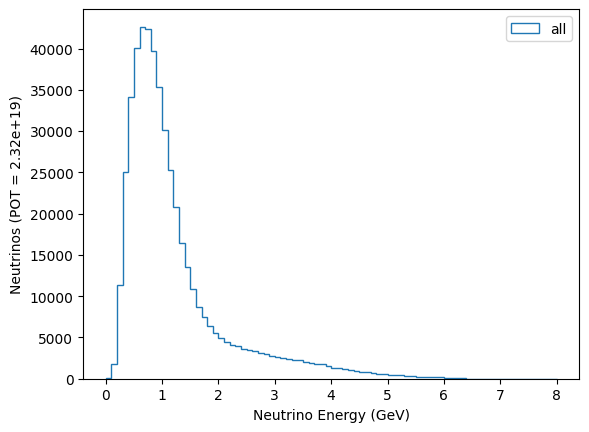

In [18]:
# True nu variables

## 1) nu.E
var = mc_nu_df.E 
plt.hist(var, bins=np.linspace(0., 8., 81), weights=[np.ones_like(data) * 1. for data in var], histtype="step", label=["all"])
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel(f"Neutrinos (POT = {mc_tot_pot:.2e})")
plt.legend()
plt.show()

In [19]:
mc_matchdf = ph.multicol_merge(mc_evt_df.reset_index(), mc_nu_df.reset_index(),
                            left_on=[("entry", "",""), ("slc","tmatch", "idx", "", "", "")],
                            right_on=[("entry", "",""), ("rec.mc.nu..index", "","")], 
                            how="left") ## -- save all sllices

NameError: name 'mc_evt_df' is not defined

In [ ]:
mc_matchdf

In [ ]:
## -- Make unmatched slice to have nuint_categ = -2
notmatcheddf = mc_matchdf[pd.isna(mc_matchdf.nuint_categ)]
matcheddf = mc_matchdf[~pd.isna(mc_matchdf.nuint_categ)]
notmatcheddf.nuint_categ = -2
mc_matchdf = pd.concat([matcheddf, notmatcheddf])

In [ ]:
mc_matchdf = mc_matchdf.set_index(['entry', 'rec.slc..index', 'rec.slc.reco.pfp..index'])

In [ ]:
mc_matchdf

In [ ]:
## -- Label definitions for plotting
mode_list = [1, 0, 4, 5, 3, 2, -1, -2]
mode_labels = ["CC COH", "NC", "CC RES", "CC IDS", "CC 2p2h", "CC QE", "Non-FV", "Others"]
colors = [#'#d62728',  # Red            
          '#1f77b4',  # Blue
          '#ff7f0e',  # Orange
          '#2ca02c',  # Green
          '#17becf',  # Teal
          '#9467bd',  # Purple
          '#8c564b',  # Brown
          '#e377c2',  # Pink
          '#7f7f7f']  # Gray
          #'#bcbd22',  # Yellow-green
          #'#17becf']  # Teal

def draw_reco_stacked_hist(var, is_logy, title_x, title_y, x_min, x_max, nbins, outname, data_overlay = False, var_data = []):
    plt.figure(figsize=(800/100, 600/100), dpi=100)
    POT_scale = 1.
    # No data overlay — keep original logic
    hist_data, bins, _ = plt.hist(var,
                                    bins=np.linspace(x_min, x_max, nbins + 1),
                                    weights=[np.ones_like(data) * POT_scale for data in var],
                                    stacked=True,
                                    color=colors,
                                    label=mode_labels,
                                    edgecolor='none',
                                    linewidth=0,
                                    density=data_overlay,
                                histtype='stepfilled')
    max_y = np.max([np.sum(vals) for vals in zip(*hist_data)])
    print(max_y)
    plt.xlim(x_min, x_max)
    plt.ylim(0.0, max_y * 1.5)
    plt.xlabel(title_x)
    plt.ylabel(title_y)
    if is_logy:
        plt.ylim(0.1, max_y * 600)
        plt.yscale('log')
    
    if data_overlay:
        plt.ylabel("A.U.")
        # Normalize data by area
        counts, _ = np.histogram(var_data, bins=np.linspace(x_min, x_max, nbins + 1))
        bin_widths = np.diff(np.linspace(x_min, x_max, nbins + 1))
        total_data = np.sum(counts)
        norm_counts = counts / (total_data * bin_widths)
        errors = np.sqrt(counts) / (total_data * bin_widths) if total_data > 0 else np.zeros_like(counts)
        bin_centers = 0.5 * (np.linspace(x_min, x_max, nbins + 1)[:-1] + np.linspace(x_min, x_max, nbins + 1)[1:])

        # -- non-zero mask
        nonzero_mask = counts > 0
        bin_centers = bin_centers[nonzero_mask]
        norm_counts = norm_counts[nonzero_mask]
        errors = errors[nonzero_mask]
        
        # Plot data with error bars
        plt.errorbar(bin_centers, norm_counts, yerr=errors,
                     fmt='o', color='black', label='Data',
                     markersize=5, capsize=3, linewidth=1.5)


    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(width=2, length=10)

    accum_sum = [np.sum(data) for data in hist_data]
    accum_sum = [0.] + accum_sum
    total_sum = accum_sum[-1]
    print(total_sum)
    individual_sums = [accum_sum[i+1] - accum_sum[i] for i in range(len(accum_sum) - 1)]
    fractions = [(count / total_sum) * 100 for count in individual_sums]
    legend_labels = [f"{label} ({frac:.1f}%)" for label, frac in zip(mode_labels[::-1], fractions[::-1])]
    if data_overlay:
        legend_labels.append("Data")
    colors_reversed = colors[::-1]  # Ensure colors match reversed labels
    plt.legend(legend_labels, loc='upper left', fontsize=11, frameon=False, ncol=3, bbox_to_anchor=(0.05, 0.98))
    
    plt.text(0.00, 1.02, "SBND Sample (2025A Dev.), Preliminary", transform=plt.gca().transAxes,
             fontsize = 14, fontweight = 'bold')
    #plt.savefig("../output/plots/reco_slc/" + outname + ".pdf", format='pdf')
    plt.show()

In [ ]:
def draw_mc_data_shape_comp_per_slc(mc_df, data_df, column, x_title, y_title, x_min, x_max, n_bins, out_name):
    nuint_categ_col = ('nuint_categ', '', '', '', '', '')
    mc_df_per_slc = mc_df.groupby([('entry'), ('rec.slc..index')])[[column, nuint_categ_col]].first()
    data_df_per_slc = data_df.groupby([('entry'), ('rec.slc..index')])[[column]].first()
    var_mc = [mc_df_per_slc[mc_df_per_slc.nuint_categ == mode][column] for mode in mode_list]
    var_data = data_df_per_slc[column]
    draw_reco_stacked_hist(var_mc, False, x_title, y_title, x_min, x_max, n_bins, out_name, True, var_data)

In [ ]:
def draw_reco_valid_plots(mc_df, data_df, suffix):
    ## draw 1) clear cosmic, 2) nu score, 3) vertex x,y and z
    
    ## -- 1) Clear cosmic
    clear_cosmic_col = ('slc', 'is_clear_cosmic', '', '', '', '')
    draw_mc_data_shape_comp_per_slc(mc_df, data_df, clear_cosmic_col, "Is Clear Cosmic", "A.U.", -0.5, 1.5, 2, suffix + "_slc_is_clear_cosmic")

    ## -- 2) nu score
    nu_score_col = ('slc', 'nu_score', '', '', '', '')
    draw_mc_data_shape_comp_per_slc(mc_df, data_df, nu_score_col, "Nu Score", "A.U.", -1.1, 1.1, 44, suffix + "_slc_nu_score")

    ## -- 3) vertex x,y,z
    vtx_x_col = ('slc', 'vertex', 'x', '', '', '')
    vtx_y_col = ('slc', 'vertex', 'y', '', '', '')
    vtx_z_col = ('slc', 'vertex', 'z', '', '', '')
    draw_mc_data_shape_comp_per_slc(mc_df, data_df, vtx_x_col, "Slice Vertex X [cm]", "A.U.", -300, 300, 100, suffix + "_slc_vtx_x")
    draw_mc_data_shape_comp_per_slc(mc_df, data_df, vtx_y_col, "Slice Vertex Y [cm]", "A.U.", -300, 300, 100, suffix + "_slc_vtx_y")
    draw_mc_data_shape_comp_per_slc(mc_df, data_df, vtx_z_col, "Slice Vertex Z [cm]", "A.U.", -100, 600, 100, suffix + "_slc_vtx_z")

    

In [ ]:
## Reco 1) Nocut
draw_reco_valid_plots(mc_matchdf, data_evt_df, "nocut")

In [ ]:
## Reco 2) FV cut
is_fv_mc = InFV(mc_matchdf.slc.vertex, 0, 0, 0, 0, "SBND")
is_fv_data = InFV(data_evt_df.slc.vertex, 0, 0, 0, 0, "SBND")

mc_matchdf = mc_matchdf[is_fv_mc]
data_evt_df = data_evt_df[is_fv_data]

draw_reco_valid_plots(mc_matchdf, data_evt_df, "nocut")

In [ ]:
## Reco 3) !is_clear_cosmic
isnt_clear_cosmic_mc = (mc_matchdf.slc.is_clear_cosmic == 0)
isnt_clear_cosmic_data = (data_evt_df.slc.is_clear_cosmic == 0)

mc_matchdf = mc_matchdf[isnt_clear_cosmic_mc]
data_evt_df = data_evt_df[isnt_clear_cosmic_data]

draw_reco_valid_plots(mc_matchdf, data_evt_df, "is_clear_cosmic")

In [ ]:
def dist_pfptrk_vertex(df):
    this_vertex_x = df[('slc', 'vertex', 'x', '', '', '')]
    this_vertex_y = df[('slc', 'vertex', 'y', '', '', '')]
    this_vertex_z = df[('slc', 'vertex', 'z', '', '', '')]

    this_pfp_start_x = df[('pfp', 'trk', 'start', 'x', '', '')]
    this_pfp_start_y = df[('pfp', 'trk', 'start', 'y', '', '')]
    this_pfp_start_z = df[('pfp', 'trk', 'start', 'z', '', '')]

    this_dist = np.sqrt(
        (this_vertex_x - this_pfp_start_x) ** 2 +
        (this_vertex_y - this_pfp_start_y) ** 2 +
        (this_vertex_z - this_pfp_start_z) ** 2
    )

    return this_dist

def add_pfp_len_cut_multi_col(df, len_cut = 4., vtx_dist_cut = 6., n_trk_len_col = 'n_trk_4cm', n_trk_dist_col = 'n_trk_vtx_dist_6cm'):
    ## pfp trk len > 4 cm
    cut_trk_len = df.pfp.trk.len > len_cut
    n_trk_df = cut_trk_len.reset_index(name='len')
    all_combinations = (
        n_trk_df[['entry', 'rec.slc..index']].drop_duplicates().set_index(['entry', 'rec.slc..index'])
    )
    n_trk_df = (
        n_trk_df[n_trk_df['len'] == True]
        .groupby(['entry', 'rec.slc..index'])
        .size()
        .reindex(all_combinations.index, fill_value=0)
    )
    df[('rec', n_trk_len_col, '', '', '', '')] = n_trk_df


    ## and pfp trk vtx dist < 6 cm
    vtx_dist_df_series = dist_pfptrk_vertex(df)
    cut_vtx_dist = vtx_dist_df_series < vtx_dist_cut
    cut_vtx_dist = cut_vtx_dist & cut_trk_len
    n_vtx_dist_df = cut_vtx_dist.reset_index(name='len')

    all_combinations = (
        n_vtx_dist_df[['entry', 'rec.slc..index']].drop_duplicates().set_index(['entry', 'rec.slc..index'])
    )
    n_vtx_dist_df = (
        n_vtx_dist_df[n_vtx_dist_df['len'] == True]
        .groupby(['entry', 'rec.slc..index'])
        .size()
        .reindex(all_combinations.index, fill_value=0)
    )
    df[('rec', n_trk_dist_col, '', '', '', '')] = n_vtx_dist_df
    df[('pfp', 'trk', 'pass_vtx_dist', '', '', '')] = cut_vtx_dist

In [ ]:
add_pfp_len_cut_multi_col(data_evt_df)
add_pfp_len_cut_multi_col(mc_matchdf)

In [ ]:
## Reco 4) n(pfp track with len > 4cm) = 2 
n_pfp_trk_4cm_cut_mc = (mc_matchdf.rec.n_trk_4cm > 1)
n_pfp_trk_4cm_cut_data = (data_evt_df.rec.n_trk_4cm > 1)

mc_matchdf = mc_matchdf[n_pfp_trk_4cm_cut_mc]
data_evt_df = data_evt_df[n_pfp_trk_4cm_cut_data]

draw_reco_valid_plots(mc_matchdf, data_evt_df, "n_pfp_trk_4cm")

In [ ]:
## Reco 5) n(pfp track with len > 4cm && vtx dist < 6 cm) = 2 
n_trk_vtx_dist_6cm_cut_mc = (mc_matchdf.rec.n_trk_vtx_dist_6cm == 2)
n_trk_vtx_dist_6cm_cut_data = (data_evt_df.rec.n_trk_vtx_dist_6cm == 2)

mc_matchdf = mc_matchdf[n_trk_vtx_dist_6cm_cut_mc]
data_evt_df = data_evt_df[n_trk_vtx_dist_6cm_cut_data]

draw_reco_valid_plots(mc_matchdf, data_evt_df, "n_pfp_trk_4cm")

In [ ]:
data_evt_df

In [ ]:
def opening_angle(n_trk_vtx_dist, dir_x, dir_y, dir_z, trk_vtx_dist_pass):
    #print("opening_angle")                                                                                                                                                                                                                                                     
    if n_trk_vtx_dist != 2:
        return -999.
    dir_x = dir_x[trk_vtx_dist_pass]
    dir_y = dir_y[trk_vtx_dist_pass]
    dir_z = dir_z[trk_vtx_dist_pass]
    if(dir_x.size != 2):
        print("error, dir_x.len != 2")
        return -888.

    this_cos_theta = dir_x.iloc[0] * dir_x.iloc[1] + dir_y.iloc[0] * dir_y.iloc[1] + dir_z.iloc[0] * dir_z.iloc[1]
    return this_cos_theta

def measure_opening_angle(group):
    n_trk_vtx_dist = group[('rec', 'n_trk_vtx_dist_6cm', '', '', '', '')].iloc[0]
    dir_x = group[('pfp', 'trk', 'dir', 'x', '', '')]
    dir_y = group[('pfp', 'trk', 'dir', 'y', '', '')]
    dir_z = group[('pfp', 'trk', 'dir', 'z', '', '')]
    trk_vtx_dist_pass = group[('pfp', 'trk', 'pass_vtx_dist', '', '', '')]

    # Call reco_t function                                                                                                                                                                                                                                                      
    return opening_angle(n_trk_vtx_dist, dir_x, dir_y, dir_z, trk_vtx_dist_pass)

def add_two_trk_opening_angle_col(df):
    opening_angle_series = df.groupby(['entry', 'rec.slc..index']).apply(measure_opening_angle)
    opening_angle_df = opening_angle_series.to_frame(name='reco_opening_angle')
    opening_angle_df.index.set_names(['entry', 'rec.slc..index'], inplace=True)
    df[('rec', 'opening_angle', '', '', '', '')] = opening_angle_df

In [ ]:
add_two_trk_opening_angle_col(data_evt_df)
add_two_trk_opening_angle_col(mc_matchdf)

In [ ]:
data_evt_df

In [ ]:
mc_matchdf

In [ ]:
opening_ang_col = ('rec', 'opening_angle', '', '', '', '')
draw_mc_data_shape_comp_per_slc(mc_matchdf, data_evt_df, opening_ang_col, "cos(open ang)", "A.U.", -1, 1, 100, "_opening_ang")

In [ ]:
## Reco 6) two track opening angle > -0.75
open_ang_cut_mc = (mc_matchdf.rec.opening_angle > -0.75)
open_ang_cut_data = (data_evt_df.rec.opening_angle > -0.75)

mc_matchdf = mc_matchdf[open_ang_cut_mc]
data_evt_df = data_evt_df[open_ang_cut_data]

draw_reco_valid_plots(mc_matchdf, data_evt_df, "open_angle")

In [ ]:
draw_mc_data_shape_comp_per_slc(mc_matchdf, data_evt_df, opening_ang_col, "cos(open ang)", "A.U.", -1, 1, 100, "_opening_ang")